# Taller: PCA y K-means en salud

## 1. Introducción

El análisis de componentes principales (**PCA, Principal Component Analysis**) y el agrupamiento mediante **K-means clustering** son técnicas de **aprendizaje no supervisado** ampliamente utilizadas en investigación biomédica.
Mientras que PCA permite **reducir la dimensionalidad** de los datos manteniendo la mayor parte de la variabilidad, K-means busca **descubrir patrones ocultos** agrupando a los pacientes según sus características.

En este taller exploraremos estas dos herramientas aplicadas a problemas de salud. Comenzaremos con el dataset de **cáncer de mama ([Breast Cancer](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html))**, donde trabajaremos con un escenario de clasificación binaria, y luego avanzaremos al dataset de **[Diabetes](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html)**, que contiene un resultado clínico continuo asociado a la progresión de la enfermedad.

El objetivo es que aprendas a explorar, reducir y agrupar datos biomédicos, interpretando los resultados tanto desde una perspectiva técnica como clínica. Además, generarás visualizaciones que facilitan la comprensión de estructuras complejas en datasets de salud.


## 2. Objetivos

1. **Carga y estandarización de datos biomédicos**: preparar las variables clínicas para el análisis.
2. **Reducción de dimensionalidad con PCA**: visualizar pacientes en espacios de 2D que preservan la variabilidad más importante.
3. **Clustering con K-means**: identificar posibles subgrupos o fenotipos en los datos.
4. **Evaluación del clustering**: comparar resultados con etiquetas reales (Breast Cancer) o métricas como silhouette (Diabetes).
5. **Visualización de resultados**: generar gráficos en 2D para interpretar los patrones encontrados.
6. **Discusión clínica**: analizar cómo estas técnicas pueden apoyar el diagnóstico, el pronóstico y la investigación en salud.



## 3. Importar librerias

In [66]:
# Librerias generales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 4. Dataset cáncer de mama

El Breast Cancer Dataset es un conjunto de datos ampliamente utilizado en el aprendizaje automático aplicado a la medicina. Su objetivo es clasificar tumores de mama en dos categorías:

- **M** = maligno  
- **B** = benigno  

### Características principales
- **Número de instancias:** 569  
- **Número de variables:** 30 (numéricas reales)  
- **Variable objetivo:** `Diagnosis` (M/B)  
- **Tarea principal:** Clasificación supervisada  

### Variables
Las características corresponden a medidas de núcleos celulares. Cada una se resume en **media, error estándar y máximo**, resultando en 30 variables en total. Entre ellas destacan:  

- **Radio:** media de distancias desde el centro al perímetro.  
- **Textura:** desviación estándar de los valores en escala de grises.  
- **Perímetro y Área.**  
- **Suavidad:** variación local de radios.  
- **Compacidad:** (perímetro² / área − 1).  
- **Concavidad y puntos cóncavos:** severidad y número de partes cóncavas del contorno.  
- **Simetría.**  
- **Dimensión fractal:** aproximación tipo “línea de costa”.  






#### **Ejercicio 1** 

1. Carga el dataset desde scikit-learn. HINT: puedes utilizar la función `load_breast_cancer`
2. Inspeccióna forma, tipos y valores faltantes
3. Revisar distribución de clases (0=maligno, 1=benigno)
4. Explorar la relación entre las variables mediante una matrix de correlación
5. Responda:
    * ¿Qué indica la alta correlación entre ciertas variables?
    * ¿Qué implicancias tiene para el análisis posterior?


In [67]:
# <CODE> 1. Cargar dataset
from sklearn.datasets import load_breast_cancer
bc = load_breast_cancer()
Y = pd.Series(bc.target, name='target')
X = pd.DataFrame(bc.data, columns=bc.feature_names)

In [68]:
# <CODE> 2. Vistazo general
print("=== Breast Cancer: shape ===")
print("X:", X.shape, " | y:", Y.shape, "\n")

print("=== Tipos de datos (todas numéricas) ===")
print(X.dtypes.value_counts(), "\n")

print("=== Valores faltantes por columna (conteo) ===")
print(X.isna().sum().sort_values(ascending=False).head(10), "\n")

print("=== Filas duplicadas en X ===")
print(X.duplicated().sum(), "\n")

=== Breast Cancer: shape ===
X: (569, 30)  | y: (569,) 

=== Tipos de datos (todas numéricas) ===
float64    30
Name: count, dtype: int64 

=== Valores faltantes por columna (conteo) ===
mean radius               0
mean texture              0
mean perimeter            0
mean area                 0
mean smoothness           0
mean compactness          0
mean concavity            0
mean concave points       0
mean symmetry             0
mean fractal dimension    0
dtype: int64 

=== Filas duplicadas en X ===
0 



=== Distribución de la clase (0=maligno, 1=benigno) ===
target
1    357
0    212
Name: conteo, dtype: int64
target
1    62.74
0    37.26
Name: %, dtype: float64 



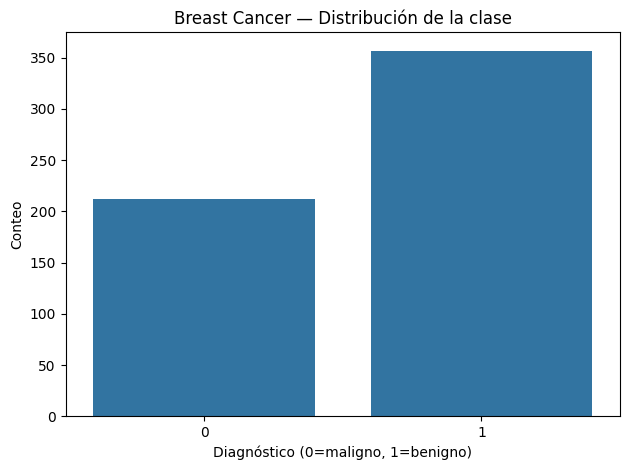

In [69]:
# <CODE> 3 Distribución de la clase
print("=== Distribución de la clase (0=maligno, 1=benigno) ===")
print(Y.value_counts().rename("conteo"))
print((Y.value_counts(normalize=True)*100).round(2).rename("%"), "\n")

fig, ax = plt.subplots()
sns.countplot(x=Y, ax=ax)
ax.set_title("Breast Cancer — Distribución de la clase")
ax.set_xlabel("Diagnóstico (0=maligno, 1=benigno)")
ax.set_ylabel("Conteo")
plt.tight_layout()
plt.show()

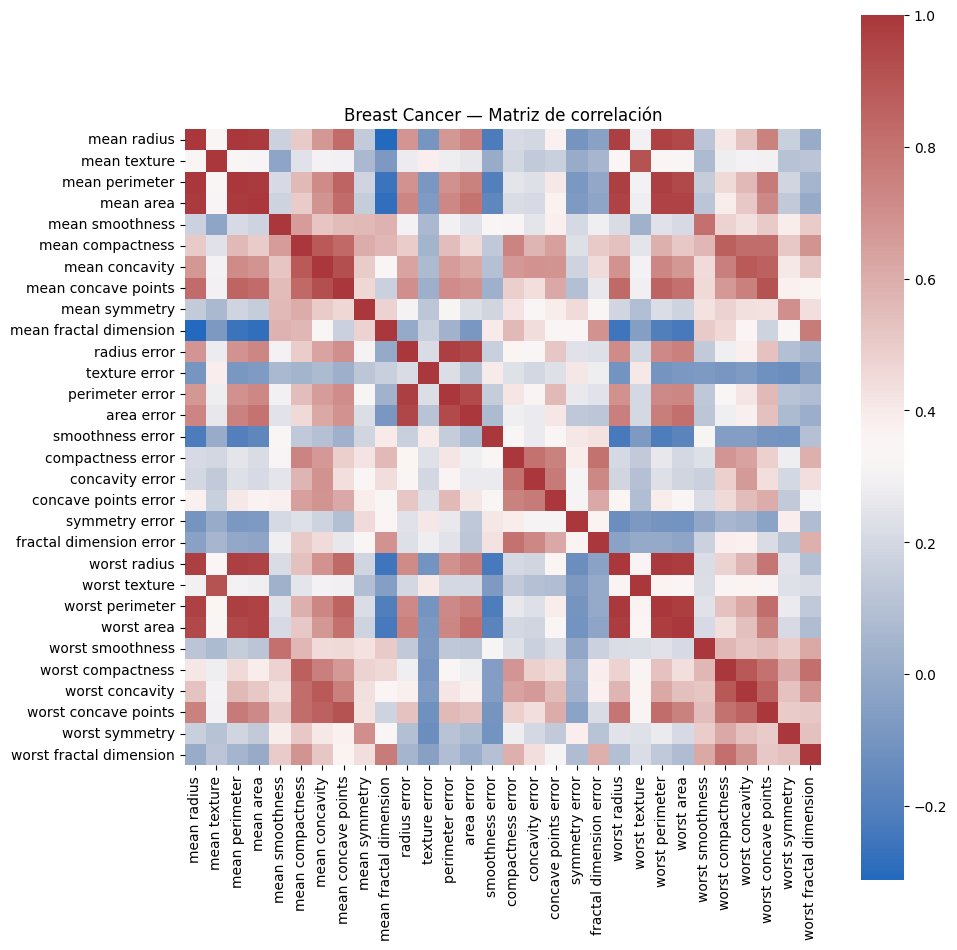

In [70]:
# <CODE> 4. Correlación entre variables
corr = X.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=False, fmt=".2f", cmap="vlag", square=True)
plt.title("Breast Cancer — Matriz de correlación")
plt.tight_layout()
plt.show()

#### **Ejercicio 2** 


1. Estandariza las variables predictoras (es importante porque PCA es sensible a la escala). HINT: puedes usar `StandardScaler` de `sklearn.preprocessing`.
2. Aplica PCA reduciendo el dataset a **2 componentes principales**. HINT: usa `PCA` de `sklearn.decomposition`.
3. Visualiza los datos en un scatter plot de PC1 vs PC2, coloreando los puntos por la clase real (0=maligno, 1=benigno).
4. Muestra la **varianza explicada** por cada componente.
5. Identifica las **variables más influyentes** en cada componente principal.
6. Responda:
   * ¿Qué significa que los dos primeros componentes expliquen un alto porcentaje de la varianza?
   * ¿Por qué es útil reducir la dimensionalidad a 2D en este caso?



In [71]:
# <CODE> 1. Estandarización
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [72]:
# <CODE> 2. PCA con 2 componentes
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

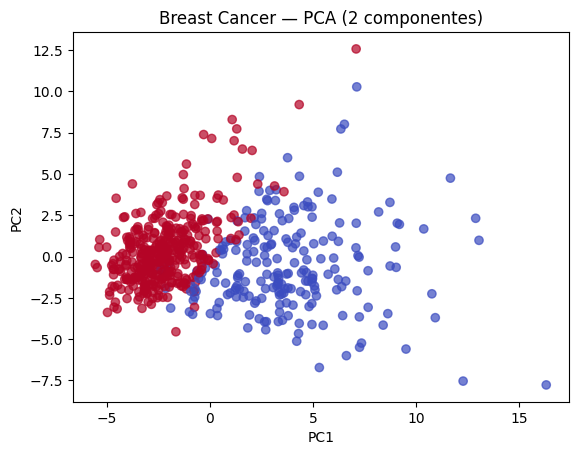

In [73]:
# <CODE> 3. Visualización PC1 vs PC2
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=Y, cmap="coolwarm", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Breast Cancer — PCA (2 componentes)")
plt.show()

In [74]:
# <CODE> 4. Varianza explicada
print("Varianza explicada por PC1 y PC2:", pca.explained_variance_ratio_)
print("Varianza acumulada (PC1+PC2):", pca.explained_variance_ratio_.sum())

Varianza explicada por PC1 y PC2: [0.44272026 0.18971182]
Varianza acumulada (PC1+PC2): 0.6324320765155944


In [75]:
# <CODE> 5. Variables más influyentes en PC1 y PC2
import pandas as pd
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=X.columns
)

print("Top variables en PC1:")
print(loadings["PC1"].abs().sort_values(ascending=False).head())

print("\nTop variables en PC2:")
print(loadings["PC2"].abs().sort_values(ascending=False).head())

Top variables en PC1:
mean concave points     0.260854
mean concavity          0.258400
worst concave points    0.250886
mean compactness        0.239285
worst perimeter         0.236640
Name: PC1, dtype: float64

Top variables en PC2:
mean fractal dimension     0.366575
fractal dimension error    0.280092
worst fractal dimension    0.275339
mean radius                0.233857
compactness error          0.232716
Name: PC2, dtype: float64


#### **Ejercicio 3** 

1. Aplicar **K-means clustering** con `k=2` sobre los datos clínicos estandarizados (sin usar etiquetas). HINT: usa `KMeans` de `sklearn.cluster`.
2. Visualizar los pacientes en 2D usando una proyección PCA **solo para graficar**.
3. Repetir el proceso aplicando primero **PCA** para reducir las dimensiones a 2 y luego correr **K-means** en ese espacio.
4. Comparar las visualizaciones:
   * ¿Los clusters se ven más definidos después de PCA?
   * ¿Es posible intuir la separación entre tipos de pacientes sin tener las etiquetas?
   * ¿Como se comparan los clusters con las etiquetas reales?


In [76]:
# <CODE> 1. K-means directo en datos originales 
from sklearn.cluster import KMeans
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans_raw = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_raw = kmeans_raw.fit_predict(X_scaled)

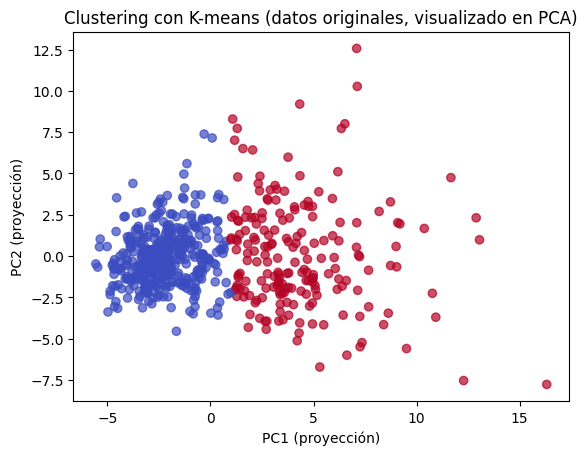

In [77]:
# <CODE> 2. Proyectamos a 2D con PCA solo para visualizar
proj_raw = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

plt.scatter(proj_raw[:, 0], proj_raw[:, 1], c=clusters_raw, cmap="coolwarm", alpha=0.7)
plt.xlabel("PC1 (proyección)")
plt.ylabel("PC2 (proyección)")
plt.title("Clustering con K-means (datos originales, visualizado en PCA)")
plt.show()

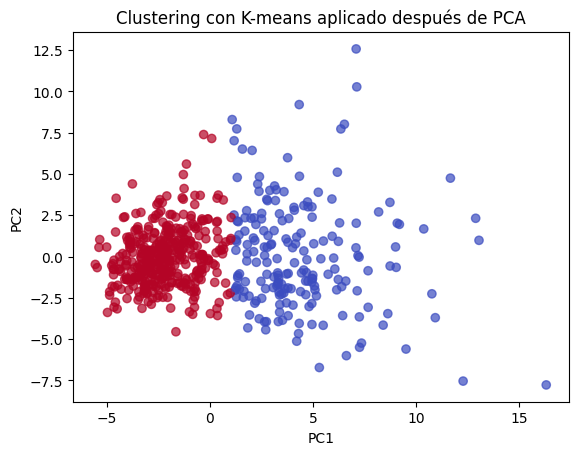

In [78]:
# <CODE> 3. K-means sobre espacio PCA 
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

kmeans_pca = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_pca = kmeans_pca.fit_predict(X_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_pca, cmap="coolwarm", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clustering con K-means aplicado después de PCA")
plt.show()


#### **Ejercicio 4** 

1. Recuerda que en la práctica muchas veces **no tenemos etiquetas** (no sabemos si un tumor es benigno o maligno).Para evaluar qué tan bien separa K-means los grupos, podemos usar el **Silhouette Score**: HINT: usa `silhouette_score` de `sklearn.metrics`.
   * Valores cercanos a **1** → clusters bien definidos y separados.
   * Valores cercanos a **0** → clusters solapados.
2. Calcula el Silhouette Score para distintos valores de `k` (ej: 2, 3 y 4).
3. Identifica qué número de clusters logra la mejor separación.
4. Responda:
   * ¿Qué valor de `k` entrega el mejor Silhouette Score?
   * ¿Qué significa esto en el contexto clínico?



k=2, silhouette=0.508


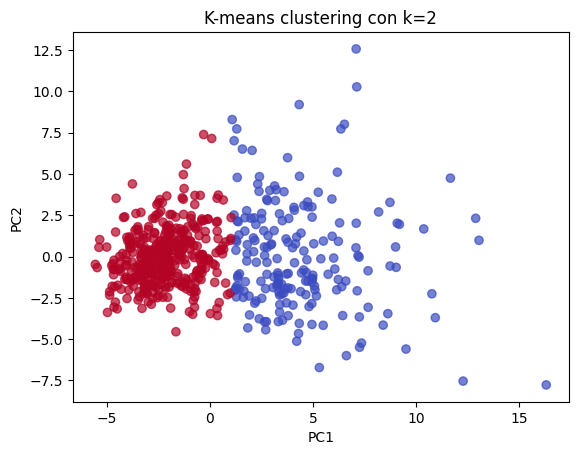

k=3, silhouette=0.477


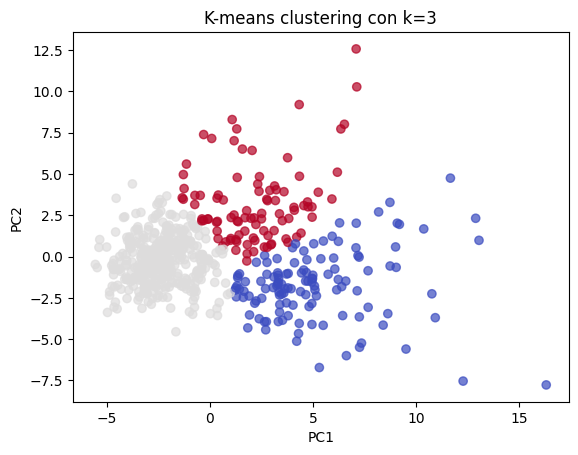

k=4, silhouette=0.465


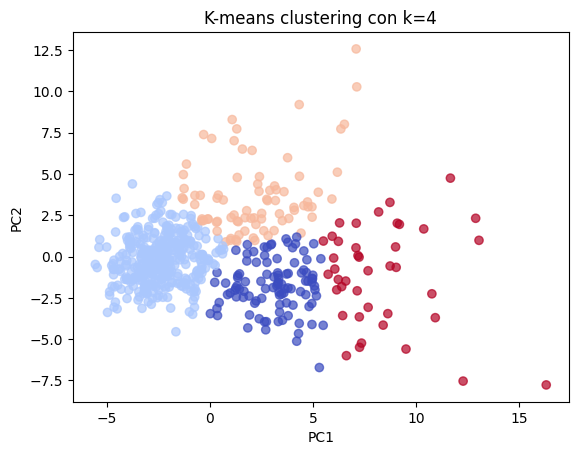

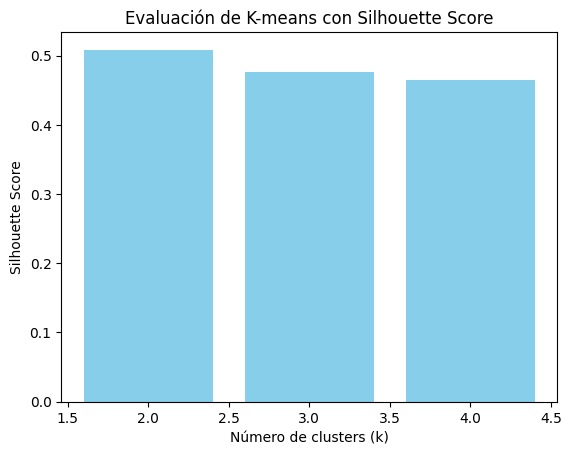

In [79]:
# <CODE> Silhouette Score para distintos k
from sklearn.metrics import silhouette_score

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

results = {}
for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, clusters)
    results[k] = score
    print(f"k={k}, silhouette={score:.3f}")
    # add plotting inside loop
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap="coolwarm", alpha=0.7)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"K-means clustering con k={k}")
    plt.show()

plt.bar(results.keys(), results.values(), color="skyblue")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Evaluación de K-means con Silhouette Score")
plt.show()






## 5. Dataset Diabetes

El dataset Diabetes de scikit-learn contiene información clínica de 442 pacientes con 10 variables predictoras estandarizadas:
* Edad 
* sexo
* IMC (bmi)
* presión arterial (bp)
* 6 medidas séricas (s1–s6).

La variable objetivo (target) corresponde a una medida continua de la progresión de la enfermedad un año después de la toma de datos iniciales.


#### **Ejercicio 6**

1. Carga la data y estandariza las variables predictoras con `StandardScaler`. HINT: puedes usar `load_diabetes` de `sklearn.datasets`.
2. Aplica PCA para reducir los datos a **2 componentes principales**.
3. Grafica un scatter plot con PC1 y PC2 en los ejes, coloreando cada paciente según su **progresión de la enfermedad (`target`)**.
   * Usa un **gradiente de color** para representar valores bajos/altos de progresión.
4. Responda:
   * ¿Se observa un patrón de gradiente de colores en la proyección PCA?
   * ¿Qué sugiere esto sobre la capacidad de PCA de resumir la variabilidad relacionada con la progresión?



In [80]:
# <CODE> 1. Cargar dataset
from sklearn.datasets import load_diabetes
db = load_diabetes()
X = pd.DataFrame(db.data, columns=db.feature_names)
Y = pd.Series(db.target, name="progresión")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[[ 's1', 's2', 's3', 's4', 's5', 's6']])



In [81]:
# <CODE> 2. PCA con 2 componentes
pca = PCA(n_components=4, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada PC1 y PC2:", pca.explained_variance_ratio_)
print("Varianza acumulada:", pca.explained_variance_ratio_.sum())


Varianza explicada PC1 y PC2: [0.54594331 0.21808828 0.13336092 0.08775054]
Varianza acumulada: 0.985143053979864


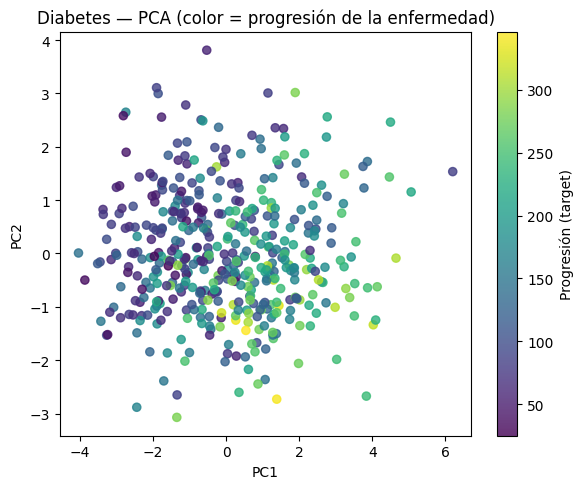

In [82]:
# <CODE> 3. Visualización coloreada por target (progresión)
plt.figure(figsize=(6,5))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=Y, cmap="viridis", alpha=0.8, s=35)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Diabetes — PCA (color = progresión de la enfermedad)")
cbar = plt.colorbar(sc)
cbar.set_label("Progresión (target)")
plt.tight_layout()
plt.show()

#### **Ejercicio 7**

Para evaluar si es posible categorizar la progresión de la enfermedad, utiliza **K-means** para **agrupar** pacientes en el plano reducido por **PCA** y evaluar si estos grupos muestran **diferencias en la progresión** de la enfermedad.

1. Usa la misma proyección **PCA (PC1, PC2)** obtenida en el Ejercicio 6.
2. Aplica **K-means** con distintos valores de `k` (p. ej., 2, 3 y 4).
3. Elige el mejor `k` con **Silhouette Score**.
4. Visualiza **PC1 vs PC2** coloreando por **cluster**.
5. Compara la **progresión (`Y`)** entre clusters (boxplots) y realiza una prueba no paramétrica (**Kruskal–Wallis**) para evaluar diferencias globales entre grupos. Hint: usa `kruskal` de `scipy.stats`.
6. Responda:
   * ¿Qué `k` maximiza el Silhouette Score?
   * ¿Los clusters muestran **diferencias significativas** en progresión?
   * ¿Cómo interpretarías clínicamente estos grupos?



k=2 | silhouette=0.319


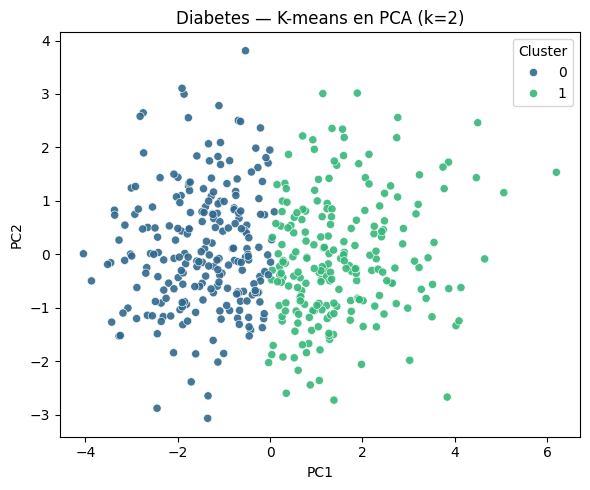

k=3 | silhouette=0.228


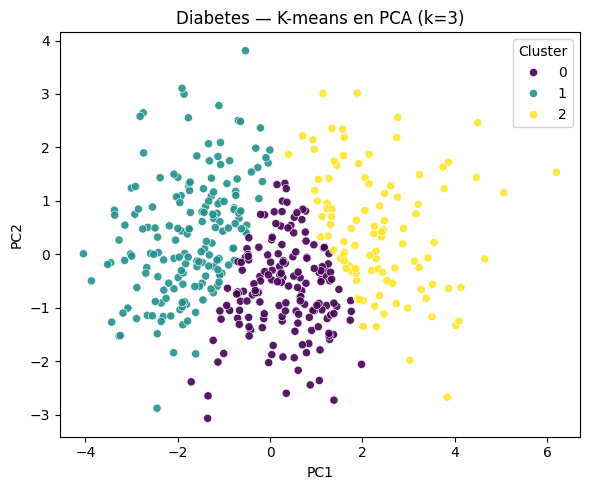

k=4 | silhouette=0.221


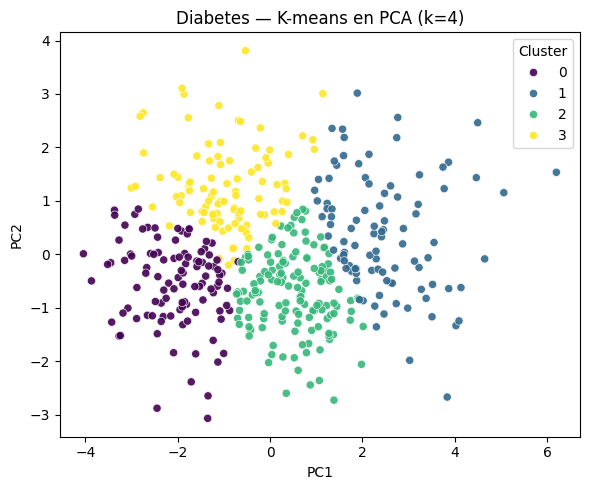

k=5 | silhouette=0.200


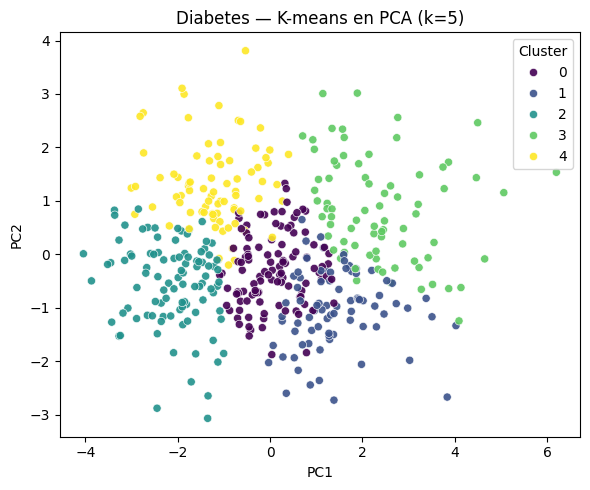

k=6 | silhouette=0.196


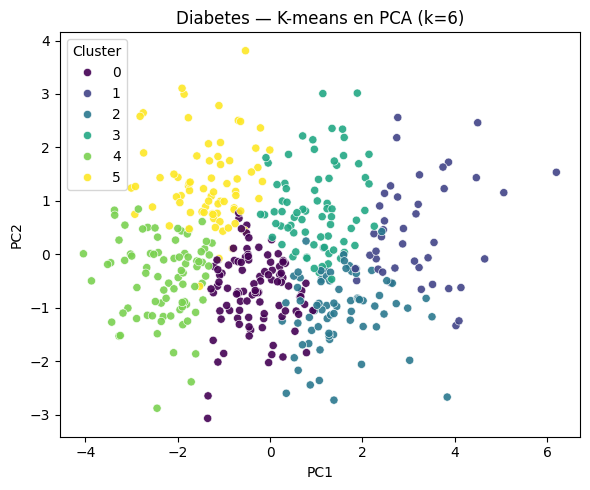

k=7 | silhouette=0.192


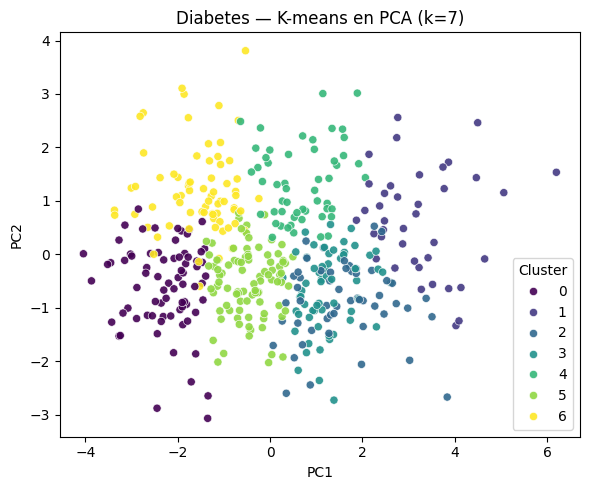


Mejor k por silhouette: k=2 (score=0.319)


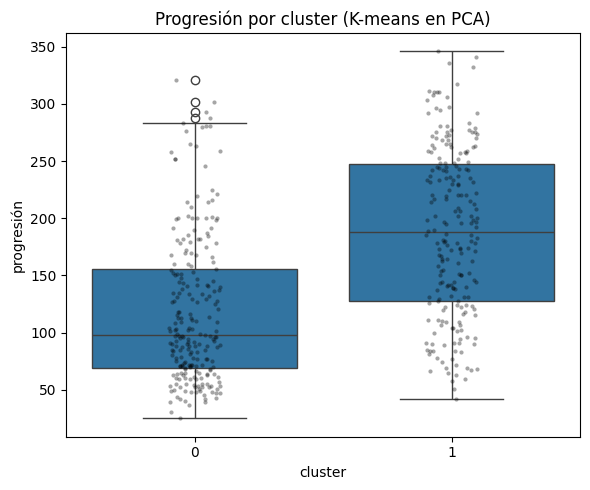

Kruskal–Wallis: H=91.754, p-value=0.0000
Hay diferencias significativas entre clusters (p <= 0.05)


In [83]:
# <CODE> 1. Compara valores de k y elige por Silhouette
results = {}
labels_by_k = {}
for k in [2, 3, 4, 5, 6 ,7]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = km.fit_predict(X_pca)
    score = silhouette_score(X_pca, clusters)
    results[k] = score
    labels_by_k[k] = clusters
    print(f"k={k} | silhouette={score:.3f}")

    # 4. Visualización de clusters en PC1-PC2
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette="viridis", s=35, alpha=0.9)
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.title(f"Diabetes — K-means en PCA (k={k})")
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.show()


# <CODE> 3. Seleccion del mejor k
best_k = max(results, key=results.get)
clusters_best = labels_by_k[best_k]
print(f"\nMejor k por silhouette: k={best_k} (score={results[best_k]:.3f})")



# <CODE> 5. Comparar la progresión entre clusters (boxplot + puntos)
df_clusters = pd.DataFrame({"cluster": clusters_best, "progresión": Y.values})
plt.figure(figsize=(6,5))
sns.boxplot(x="cluster", y="progresión", data=df_clusters)
sns.stripplot(x="cluster", y="progresión", data=df_clusters, color="k", alpha=0.35, size=3)
plt.title("Progresión por cluster (K-means en PCA)")
plt.tight_layout()
plt.show()


from scipy.stats import kruskal
groups = [df_clusters.loc[df_clusters["cluster"]==c, "progresión"].values for c in sorted(df_clusters["cluster"].unique())]
H, p = kruskal(*groups)
print(f"Kruskal–Wallis: H={H:.3f}, p-value={p:.4f}")
if p > 0.05:
    print("No hay diferencias significativas entre clusters (p > 0.05)")
else:
    print("Hay diferencias significativas entre clusters (p <= 0.05)")

